# Priority — baselines on dev

**Task.** Three classes, `Low` / `Medium` / `High`, imbalanced ~53/37/10.
Headline is **macro-F1**, because accuracy hides collapse on `High` and `High` is
the class with the operational cost.

**The thing to get right in this notebook is what counts as the bar.**

Priority is largely a function of intent — "card_lost" is High whatever the
wording. So a lookup table from intent to its most common priority is very
strong. But there are two versions of that idea and only one of them is a real
baseline:

| baseline | uses | servable? |
|---|---|---|
| `intent-lookup-oracle` | the **gold** intent of the dev row | **No** — at serving time nobody hands you the gold intent |
| `intent-chained` | intent **predicted** from text, then looked up | Yes — this is the honest bar |

Quoting the oracle as the number to beat sets an impossible target and makes a
perfectly good direct model look like a failure. A direct text→priority model
only has to beat **`intent-chained`** to justify existing.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd()
while not (REPO / "ml" / "swiftbench").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "ml"))

import pandas as pd
import matplotlib.pyplot as plt

import swiftbench as sb

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# Stamped into every result file so three people's runs stay attributable.
AUTHOR = ""

manifest = sb.splits.ensure()
print("split sha:", manifest["sha"], manifest["counts"])

split sha: e7b5934392cd {'train': 8500, 'dev': 1498, 'test': 3079}


## 1. Floors — majority, oracle, and the honest chained bar

`intent-chained` fits a real 77-way intent classifier per language first, so this
cell is the slow one.

In [2]:
floor_rows = []
for lang in sb.config.LANGUAGES:
    tr = sb.splits.get([lang], "train")
    dv = sb.splits.get([lang], "dev")

    scored = {
        "majority": sb.baselines.majority(tr, dv, "priority"),
        "intent-lookup-oracle": sb.baselines.intent_lookup(tr, dv, "priority"),
        "intent-chained": sb.baselines.intent_chained(tr, dv, "priority"),
    }
    for name, s in scored.items():
        sb.results.save("priority", name, [lang], lang, "none", "dev", s, author=AUTHOR)
        floor_rows.append({"language": lang, "model": name, "arm": "none",
                           **{k: v for k, v in s.items() if not k.startswith("_")}})
        tag = "  <- ORACLE, not a target" if s.get("is_oracle") else ""
        print(f"{lang:9s} {name:21s} macro_f1 {s['macro_f1']:.4f}  acc {s['accuracy']:.4f}{tag}")
    print()

floor_df = pd.DataFrame(floor_rows)

english   majority              macro_f1 0.2302  acc 0.5274
english   intent-lookup-oracle  macro_f1 0.9147  acc 0.9266  <- ORACLE, not a target
english   intent-chained        macro_f1 0.8931  acc 0.9045



sinhala   majority              macro_f1 0.2302  acc 0.5274
sinhala   intent-lookup-oracle  macro_f1 0.9147  acc 0.9266  <- ORACLE, not a target
sinhala   intent-chained        macro_f1 0.9011  acc 0.9126



singlish  majority              macro_f1 0.2302  acc 0.5274
singlish  intent-lookup-oracle  macro_f1 0.9147  acc 0.9266  <- ORACLE, not a target
singlish  intent-chained        macro_f1 0.9040  acc 0.9132



tamil     majority              macro_f1 0.2302  acc 0.5274
tamil     intent-lookup-oracle  macro_f1 0.9147  acc 0.9266  <- ORACLE, not a target
tamil     intent-chained        macro_f1 0.8921  acc 0.9012



tamilish  majority              macro_f1 0.2302  acc 0.5274
tamilish  intent-lookup-oracle  macro_f1 0.9147  acc 0.9266  <- ORACLE, not a target
tamilish  intent-chained        macro_f1 0.8945  acc 0.9092



### Oracle vs chained

The gap between these two bars is exactly the intent classifier's error rate
leaking into priority. It is the cost of chaining, and it is what a direct model
gets to skip.

In [3]:
gap = floor_df[floor_df.model.isin(["intent-lookup-oracle", "intent-chained"])]
gap = gap.pivot_table(index="language", columns="model", values="macro_f1").round(4)
gap["chaining_cost"] = (gap["intent-lookup-oracle"] - gap["intent-chained"]).round(4)
display(gap)

model,intent-chained,intent-lookup-oracle,chaining_cost
language,,,
english,0.8931,0.9147,0.0216
singlish,0.9040,0.9147,0.0107
sinhala,0.9011,0.9147,0.0136
tamil,0.8921,0.9147,0.0226
tamilish,0.8945,0.9147,0.0202


## 2. Direct text → priority, TF-IDF × arms

30 fits. The question is whether reading the text directly beats routing through
a predicted intent.

In [4]:
sweep_df = sb.train_classical.sweep("priority", author=AUTHOR)

priority  tfidf-logreg  arm=none         train=english              eval=english   (dev) macro_f1=0.8827 acc=0.8979


priority  tfidf-logreg  arm=class_weight train=english              eval=english   (dev) macro_f1=0.8997 acc=0.9059


priority  tfidf-logreg  arm=ros          train=english              eval=english   (dev) macro_f1=0.8937 acc=0.9012


priority  tfidf-svm     arm=none         train=english              eval=english   (dev) macro_f1=0.8999 acc=0.9045


priority  tfidf-svm     arm=class_weight train=english              eval=english   (dev) macro_f1=0.8964 acc=0.9019


...

priority  tfidf-logreg  arm=class_weight train=tamilish             eval=tamilish  (dev) macro_f1=0.8941 acc=0.9025


priority  tfidf-logreg  arm=ros          train=tamilish             eval=tamilish  (dev) macro_f1=0.8993 acc=0.9065


priority  tfidf-svm     arm=none         train=tamilish             eval=tamilish  (dev) macro_f1=0.8990 acc=0.9019


priority  tfidf-svm     arm=class_weight train=tamilish             eval=tamilish  (dev) macro_f1=0.9036 acc=0.9059


priority  tfidf-svm     arm=ros          train=tamilish             eval=tamilish  (dev) macro_f1=0.9031 acc=0.9079


## 3. Results — does direct beat chained?

In [5]:
results_df = pd.concat([floor_df, sweep_df], ignore_index=True)
results_df.to_csv(REPO / "ml" / "reports" / "priority_baselines_dev.csv", index=False)

pivot = sweep_df.pivot_table(index="language", columns=["model", "arm"],
                             values="macro_f1").round(4)
display(pivot)

best_direct = sweep_df.loc[sweep_df.groupby("language")["macro_f1"].idxmax()]
chained = floor_df[floor_df.model == "intent-chained"].set_index("language")["macro_f1"]
oracle = floor_df[floor_df.model == "intent-lookup-oracle"].set_index("language")["macro_f1"]

verdict = best_direct.set_index("language")[["model", "arm", "macro_f1"]].copy()
verdict.columns = ["best_direct_model", "arm", "direct_macro_f1"]
verdict["chained_macro_f1"] = chained
verdict["beats_chained_by"] = (verdict.direct_macro_f1 - verdict.chained_macro_f1).round(4)
verdict["oracle_macro_f1"] = oracle
display(verdict.round(4))

model    tfidf-logreg                    tfidf-svm                
arm      class_weight    none     ros class_weight    none     ros
language                                                          
english        0.8997  0.8827  0.8937       0.8964  0.8999  0.8946
singlish       0.9017  0.8852  0.9068       0.9115  0.9086  0.9068
sinhala        0.9001  0.8891  0.9062       0.9079  0.9070  0.9025
tamil          0.8966  0.8821  0.8966       0.9109  0.9017  0.9020
tamilish       0.8941  0.8847  0.8993       0.9036  0.8990  0.9031

,best_direct_model,arm,direct_macro_f1,chained_macro_f1,beats_chained_by,oracle_macro_f1
language,,,,,,
english,tfidf-svm,none,0.8999,0.8931,0.0068,0.9147
singlish,tfidf-svm,class_weight,0.9115,0.9040,0.0074,0.9147
sinhala,tfidf-svm,class_weight,0.9079,0.9011,0.0068,0.9147
tamil,tfidf-svm,class_weight,0.9109,0.8921,0.0188,0.9147
tamilish,tfidf-svm,class_weight,0.9036,0.8945,0.0091,0.9147


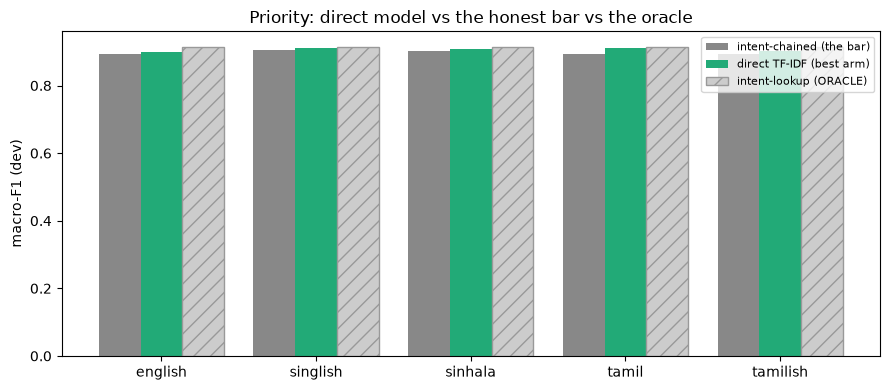

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(verdict))
w = 0.27
ax.bar([i - w for i in x], verdict.chained_macro_f1, w, label="intent-chained (the bar)", color="#888")
ax.bar(list(x), verdict.direct_macro_f1, w, label="direct TF-IDF (best arm)", color="#2a7")
ax.bar([i + w for i in x], verdict.oracle_macro_f1, w, label="intent-lookup (ORACLE)",
       color="#ccc", hatch="//", edgecolor="#999")
ax.set_xticks(list(x))
ax.set_xticklabels(verdict.index)
ax.set_ylabel("macro-F1 (dev)")
ax.set_title("Priority: direct model vs the honest bar vs the oracle")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Per-class breakdown — is `High` actually being predicted?

Macro-F1 can look respectable while `High` collapses. Check it directly.

In [7]:
display(best_direct[["language", "model", "arm", "macro_f1",
                     "f1_low", "f1_medium", "f1_high"]].round(4))

top = best_direct.sort_values("macro_f1", ascending=False).iloc[0]
fit = sb.train_classical.run("priority", top.model, [top.language], top.language,
                             arm=top.arm, save=False, verbose=False)
dv = sb.splits.get([top.language], "dev")
labels, cm = sb.metrics.confusion(dv.priority, fit["_predictions"], "priority")
print(f"\nconfusion — {top.model} / arm={top.arm} / {top.language}")
display(pd.DataFrame(cm, index=[f"true {l}" for l in labels],
                     columns=[f"pred {l}" for l in labels]))

missed_high = dv[(dv.priority == "High") & (fit["_predictions"] != "High")]
print(f"\n{len(missed_high)} High-priority tickets under-ranked. Sample:")
for _, r in missed_high.head(6).iterrows():
    print(f"  [{r.category}] {r.text_en[:90]}")

,language,model,arm,macro_f1,f1_low,f1_medium,f1_high
3,english,tfidf-svm,none,0.8999,0.9205,0.8841,0.8951
16,singlish,tfidf-svm,class_weight,0.9115,0.9320,0.9007,0.9017
10,sinhala,tfidf-svm,class_weight,0.9079,0.9329,0.9004,0.8904
22,tamil,tfidf-svm,class_weight,0.9109,0.9276,0.8936,0.9116
28,tamilish,tfidf-svm,class_weight,0.9036,0.9208,0.8847,0.9054



confusion — tfidf-svm / arm=class_weight / singlish


,pred Low,pred Medium,pred High
true Low,733,51,6
true Medium,44,508,4
true High,6,13,133



19 High-priority tickets under-ranked. Sample:
  [lost_or_stolen_card] Are you able to guide me to my card's location?
  [cancel_transfer] I need to cancel my recent transfer quickly since I made a mistake. Please help before it 
  [wrong_amount_of_cash_received] ATM is broken. It did not give me the full amount (Rs 30,000.)  I'm standing here with onl
  [transfer_not_received_by_recipient] Why did the funds not transfer to another recipient?
  [transfer_not_received_by_recipient] I sent a payment but it isn't showing up in the app
  [transfer_not_received_by_recipient] I made a transfer and they haven't received the money I sent them.


## 5. Read-out

- Majority (`Low` for everything): see table
- `intent-chained` — **the bar to beat**
- `intent-lookup-oracle` — upper bound only, never quote as a target
- Best direct model: see verdict table

If direct beats chained, priority gets its own head and stops depending on the
intent classifier's errors. If it does not, priority is better served as a
lookup hung off the intent model and there is no second model to train.

Note: this is `priority_base` — derived from ticket content alone. Real serving
priority also needs wait time and queue state, which belong in the serving
pipeline and are deliberately not baked into this dataset.